In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("E:/icu_project/models/test_predictions.csv")

print(df.head())
print("Total rows:", len(df))

   predicted_probability  true_label
0               0.028328         0.0
1               0.713363         0.0
2               0.018817         0.0
3               0.225931         0.0
4               0.508967         0.0
Total rows: 2400


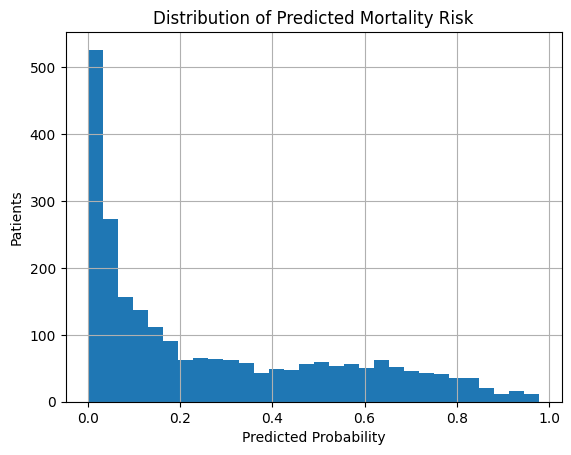

In [2]:
df["predicted_probability"].hist(bins=30)

plt.title("Distribution of Predicted Mortality Risk")
plt.xlabel("Predicted Probability")
plt.ylabel("Patients")

plt.show()

In [3]:
df["prob_bin"] = pd.cut(
    df["predicted_probability"],
    bins=10
)

risk_table = df.groupby("prob_bin")["true_label"].mean()

print(risk_table)

prob_bin
(-0.000223, 0.0985]    0.027225
(0.0985, 0.196]        0.073746
(0.196, 0.294]         0.109375
(0.294, 0.392]         0.085890
(0.392, 0.49]          0.235294
(0.49, 0.587]          0.235294
(0.587, 0.685]         0.278788
(0.685, 0.783]         0.396947
(0.783, 0.881]         0.591398
(0.881, 0.978]         0.666667
Name: true_label, dtype: float64


C:\Users\pande\AppData\Local\Temp\ipykernel_23716\3186419773.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = df.groupby("prob_bin")["true_label"].mean()


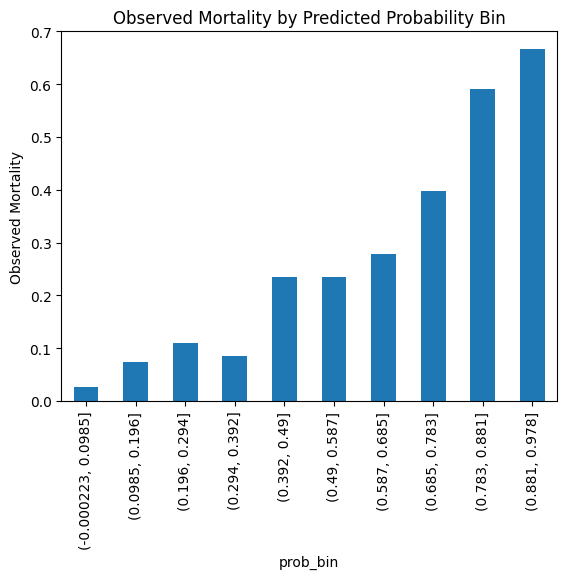

In [4]:
risk_table.plot(kind="bar")

plt.ylabel("Observed Mortality")
plt.title("Observed Mortality by Predicted Probability Bin")

plt.show()

In [5]:
risk_table.to_csv(
    "E:/icu_project/models/calibration_table.csv"
)

In [6]:
import torch

state = torch.load("E:/icu_project/session_state.pt", weights_only=True)

torch.save(state, "E:/icu_project/session_state.pt")